# IMPORTS AND LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

pd.set_option("display.width", 120)
print("Libraries loaded. 🥘, Time to cook")

Libraries loaded. 🥘, Time to cook


# MOUNT GOOGLE DRIVE

In [3]:
#Import Dataset from google drive
from pathlib import Path
from google.colab import drive; drive.mount("/content/drive")
DATA_PATH = Path("/content/drive/MyDrive/ColabNotebooks/Carisurg_2026/triage_cleaned_v1.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Unable to find {DATA_PATH}.")

Mounted at /content/drive


LOAD CLEANED DATASET

In [4]:
df = pd.read_csv(DATA_PATH, index_col=0)
print("Loaded", df.shape[0], "patients and", df.shape[1], "columns.")
df.head()

Loaded 55121 patients and 224 columns.


,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
dep_name,,,,,,,,,,,,,,,,,,,,,
A,4,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
B,2,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,2,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,3,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,2,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Features

In [5]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]


DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]

# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]

# OUTCOMES of the visit
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

In [6]:
X = df[FEATURES]     # the clues
y = df[TARGET]       # the answer

print("Model will use", len(FEATURES), "features to predict:", TARGET)
print("First few features:", FEATURES[:6], "...")

Model will use 208 features to predict: esi
First few features: ['triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device'] ...


# TRAINING AND TEST SET SPLIT

In [7]:
#TRAIN TEST SPLIT SETUP
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2, stratify=y)

print("Training patients:", X_train.shape[0])
print("Testing patients: ", X_test.shape[0])

Training patients: 44096
Testing patients:  11025


# BASELINE MODEL DUMMY

In [8]:
#Training BASELINE model

dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train)
dummy.score(X_test, y_test)

0.3683446712018141

# LOGISTIC REGRESSION

In [9]:
#SCALING FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#TRAINING MODEL
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg.score(X_test_scaled, y_test)
print(logreg.score(X_test_scaled, y_test))

0.6673015873015873


# DECISION TREE

In [10]:
#DECISION TREE
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
print(tree.score(X_test, y_test))

0.5544671201814059


# LOGISTIC REGRESSION VISUALIZATION

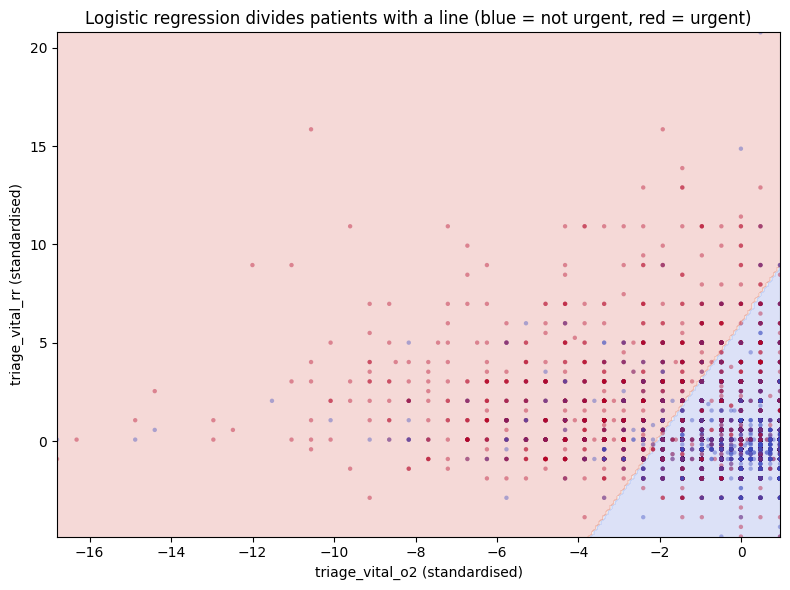

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from pathlib import Path

# Ensure the 'figs' directory exists for saving plots
Path('figs').mkdir(exist_ok=True)


f1, f2 = "triage_vital_o2", "triage_vital_rr"



urgent = (y <= 2).astype(int)


two = StandardScaler().fit_transform(X[[f1, f2]])


demo = LogisticRegression(max_iter=1000).fit(two, urgent)


xx, yy = np.meshgrid(np.linspace(two[:, 0].min(), two[:, 0].max(), 200),
                     np.linspace(two[:, 1].min(), two[:, 1].max(), 200))
zz = demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")
ax.scatter(two[:, 0], two[:, 1], c=urgent, cmap="coolwarm",
           s=10, alpha=0.4, edgecolor="none")
ax.set_xlabel(f1 + " (standardised)")
ax.set_ylabel(f2 + " (standardised)")
ax.set_title("Logistic regression divides patients with a line (blue = not urgent, red = urgent)")
plt.tight_layout()
plt.savefig("figs/w6_logreg_boundary.png", dpi=120, bbox_inches="tight")
plt.show()

# DECISION TREE

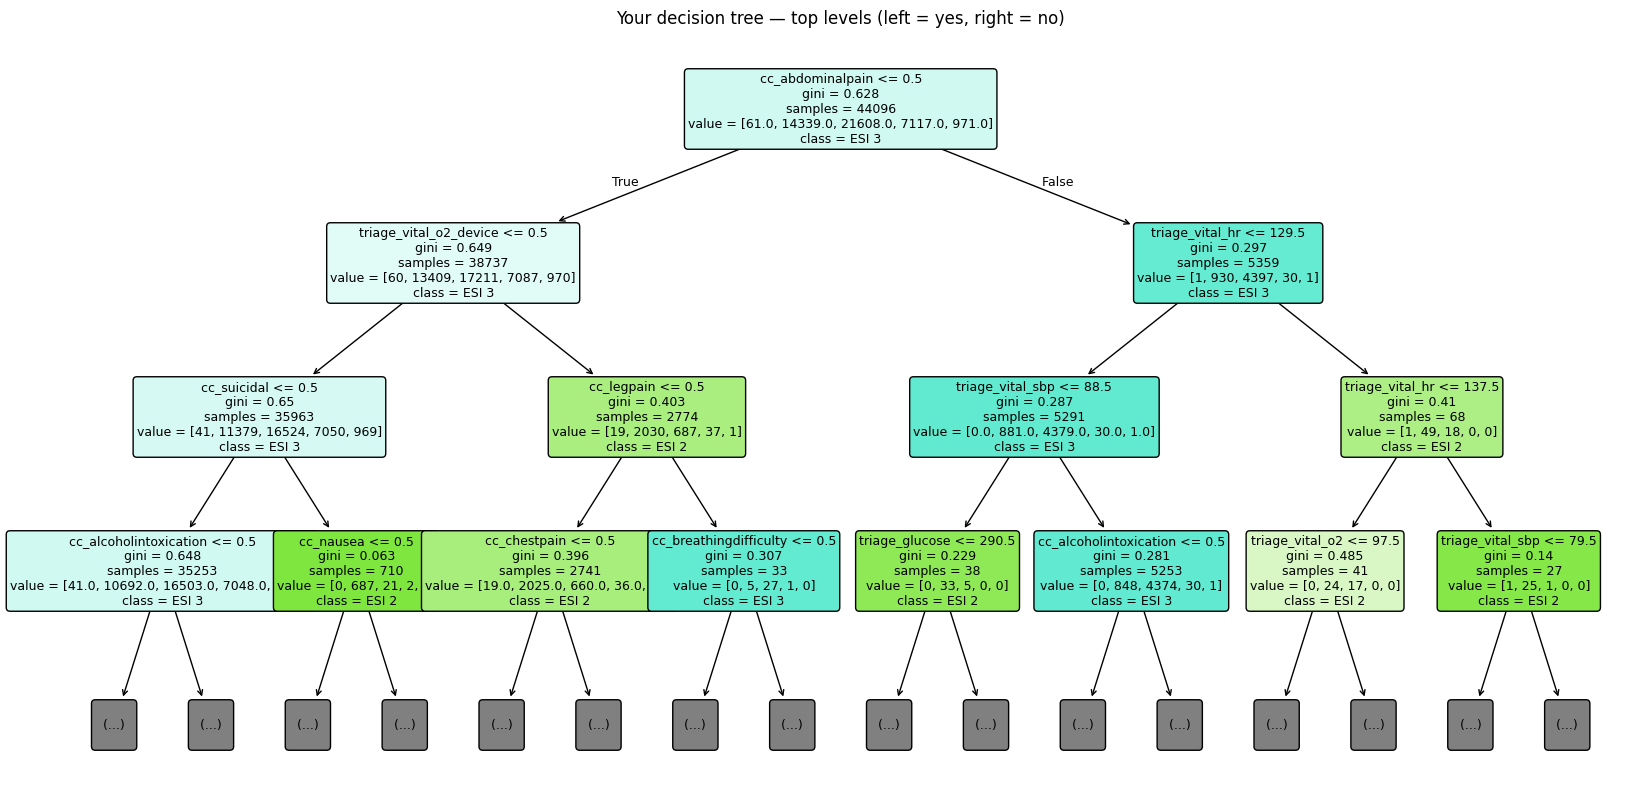

In [14]:
from sklearn.tree import plot_tree
import os

os.makedirs("figs", exist_ok=True)
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=[f"ESI {c}" for c in tree.classes_],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title("Your decision tree — top levels (left = yes, right = no)")
plt.savefig("figs/w6_decision_tree.png", dpi=120, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.tree import export_text
print(export_text(tree, feature_names=list(FEATURES), max_depth=3))

|--- cc_abdominalpain <= 0.50
|   |--- triage_vital_o2_device <= 0.50
|   |   |--- cc_suicidal <= 0.50
|   |   |   |--- cc_alcoholintoxication <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_alcoholintoxication >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_suicidal >  0.50
|   |   |   |--- cc_nausea <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_nausea >  0.50
|   |   |   |   |--- class: 3
|   |--- triage_vital_o2_device >  0.50
|   |   |--- cc_legpain <= 0.50
|   |   |   |--- cc_chestpain <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_chestpain >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cc_legpain >  0.50
|   |   |   |--- cc_breathingdifficulty <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cc_breathingdifficulty >  0.50
|   |   |   |   |--- class: 2
|--- cc_abdominalpain >  0.50
|   |--- triage_vital_hr <= 129.50
|  

# SAVING TRAINED MODELS

In [16]:
joblib.dump(logreg, "model_logreg.joblib")
joblib.dump(tree,   "model_tree.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅")

Saved: model_logreg.joblib, model_tree.joblib, scaler.joblib ✅
